# DSC355 Week 1: Exploratory Data Analysis

##  1. Import Libraries 

Import Python libraries that will be used to load, clean, analyze and visualize data. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

The eda_data.csv file will be loaded into a Pandas Dataframe so it can be organized and analyzed.

In [2]:
df = pd.read_csv('eda_data.csv')

## 3. Understand the Dataset

I will examine the structure of the dataset to get a better understanding of next steps for this dataset. This will include
- finding the shape of the dataset
- identifying the column names
- determine data types for features

In [3]:
df.shape

df.columns

df.info

<bound method DataFrame.info of              x0         x1         x2         x3         x4         x5  \
0    -17.933519   6.559220 -14.452810  -4.732855   0.381673   2.563194   
1    -37.214754  10.774930 -15.384004  -0.077339  10.983774 -15.210206   
2      0.330441 -19.609972  -9.167911   2.064124  12.071688  12.506141   
3    -13.709765  -8.011390   6.759264   1.727615  -1.768382  24.039733   
4     -4.202598   7.076210 -26.004919  -4.269696  -3.414224   2.115989   
...         ...        ...        ...        ...        ...        ...   
9994  -1.967405 -25.561679  28.188776   1.150223  -1.887983 -10.482834   
9995  41.257961  -0.264639  11.293025  -5.768300   4.088754   0.300116   
9996  11.431402 -28.363664 -35.619430  10.238941   6.494562  -0.407489   
9997 -19.039869 -20.251227  -3.002298  -1.039843  10.741492 -26.970477   
9998 -48.567163   5.209877 -43.120062   2.945213   0.804878  -7.292381   

               x6          x7         x8          x9     x10       x11  \
0    

### Initial Observations

Based on the initial viewing of the dataset I can see there are 10,000 observations and 15 features. There are numeric and object data types included in this dataset. 

## 4. Check for Missing Values and Duplicate Rows 

Missing values and duplicate rows can affect statistical analysis. 
The dataset will be checked for missing values and duplicate rows. 


In [4]:
# missing values
df.isnull().sum()

# duplicate rows
df.duplicated().sum()

np.int64(0)

### Observations

There are not missing values or duplicate rows in this dataset. 

## 5. Descriptive Analytics and Univariate EDA

Descriptive statistics and univariate EDA were used to individually examine numerical variables. Summary statistics and histograms are used to describe the measures of central tendency and look at the distributions of each variable. A function will be created to find summary statistics and create histograms to avoid redundant coding.

In [6]:
# identify numerical variables
numeric = df.select_dtypes(include=np.number).columns

numeric

Index(['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x7', 'x8', 'x9', 'x11', 'x12',
       'x13', 'y'],
      dtype='object')

All columns are numerical except 'x6' and 'x10'.

In [19]:
def desc_num_feature(feature_name, bins=30, edgecolor='k', **kwargs):
    fig, ax = plt.subplots(figsize=(8,4))
    df[feature_name].hist(
        bins=bins,
        edgecolor=edgecolor,
        ax=ax,
        **kwargs
    )
    ax.set_title(feature_name, size=15)
    plt.figtext(
        1, .15, 
        str(df[feature_name].describe().round(2)),
        size=10
    )

    plt.show()
    plt.close(fig)

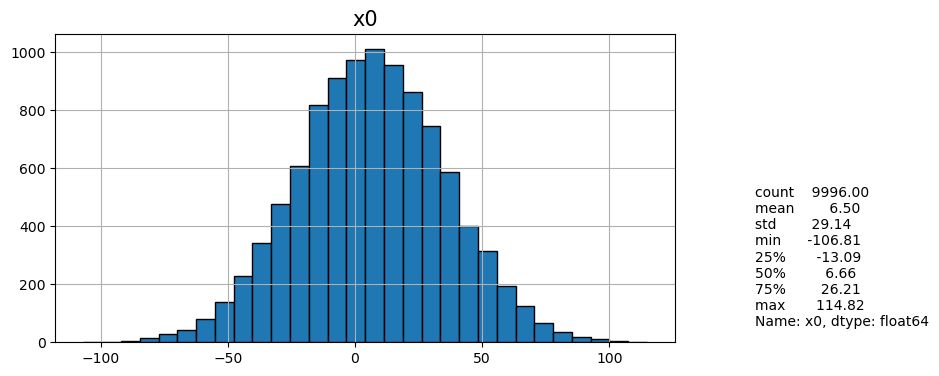

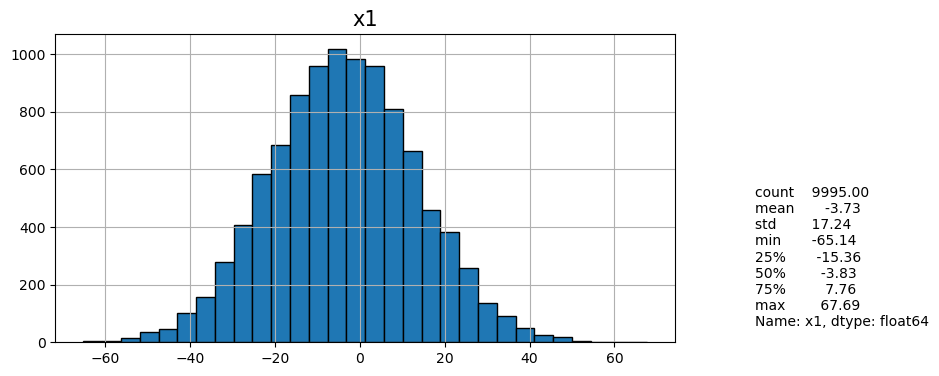

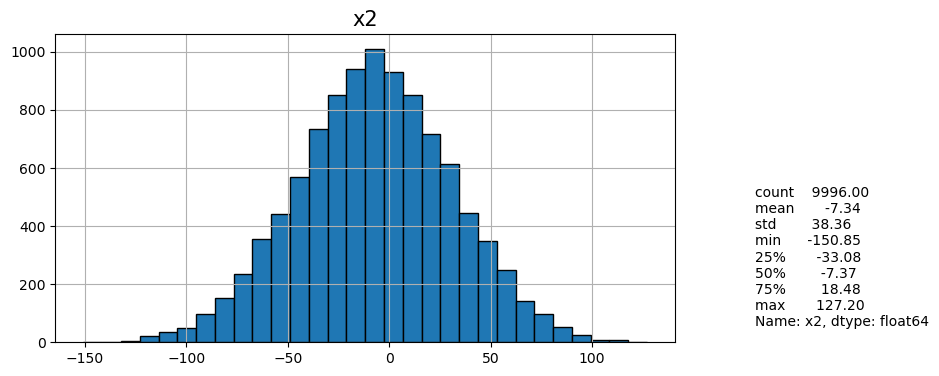

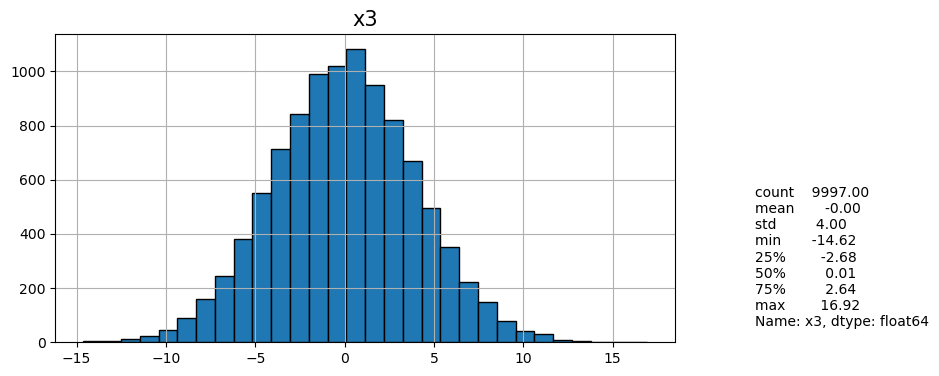

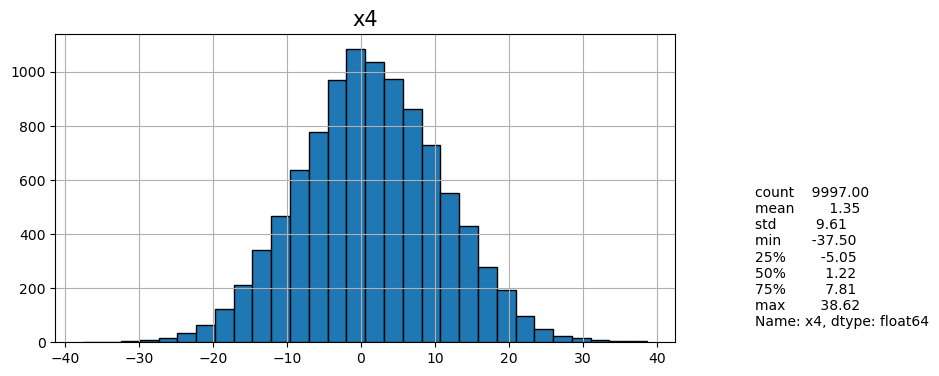

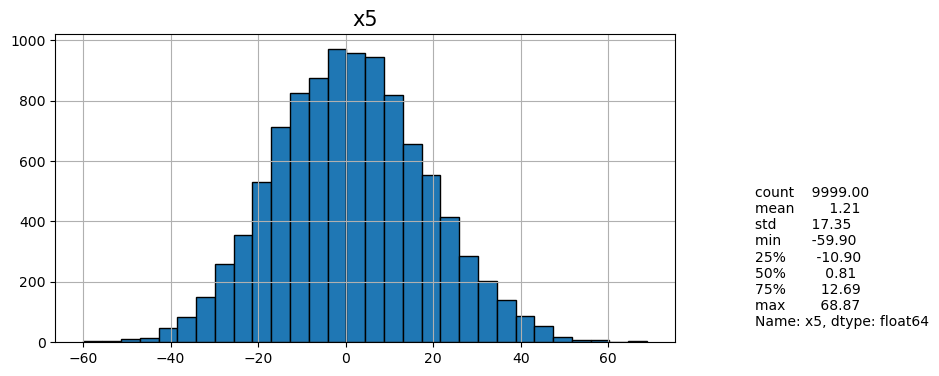

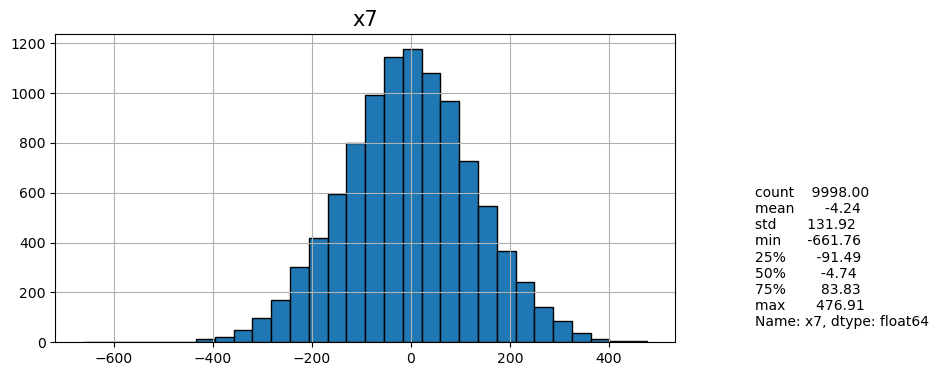

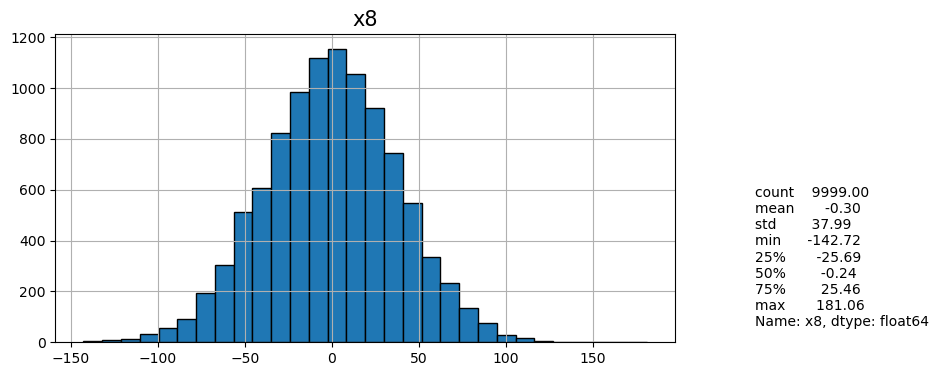

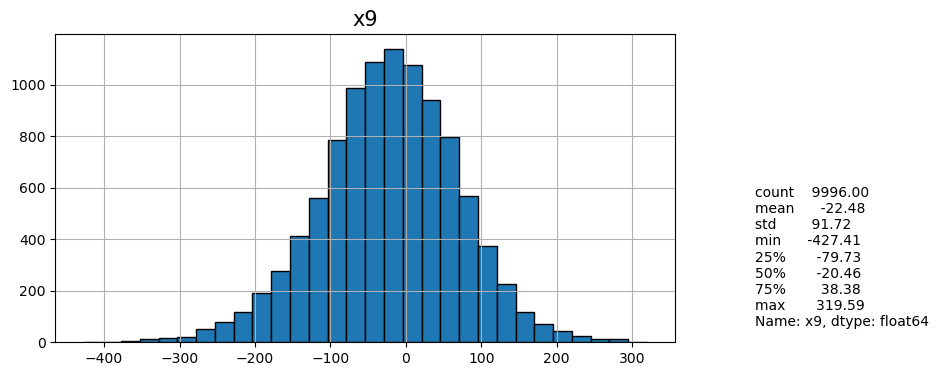

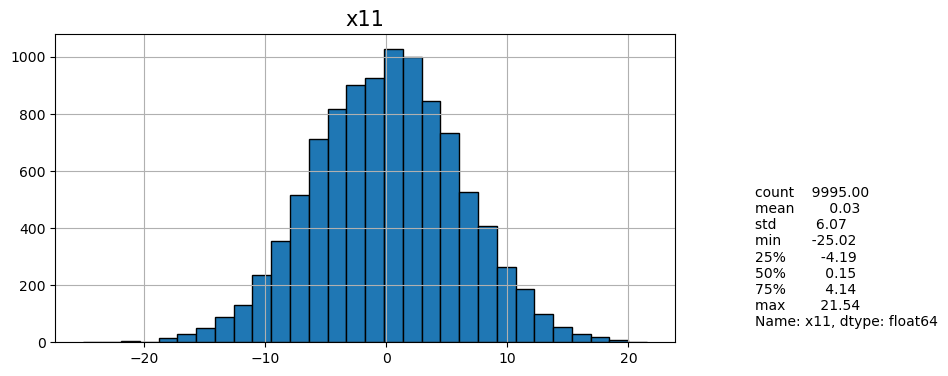

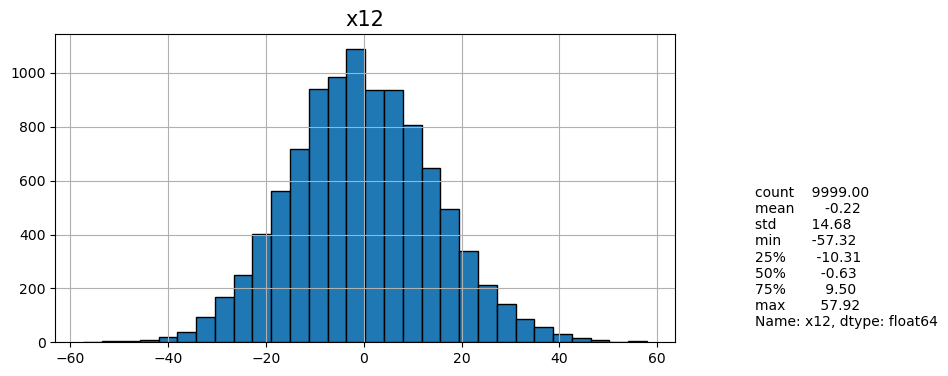

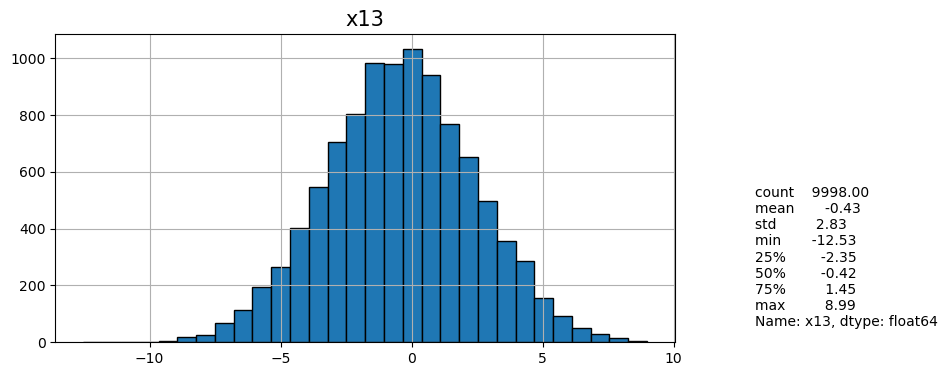

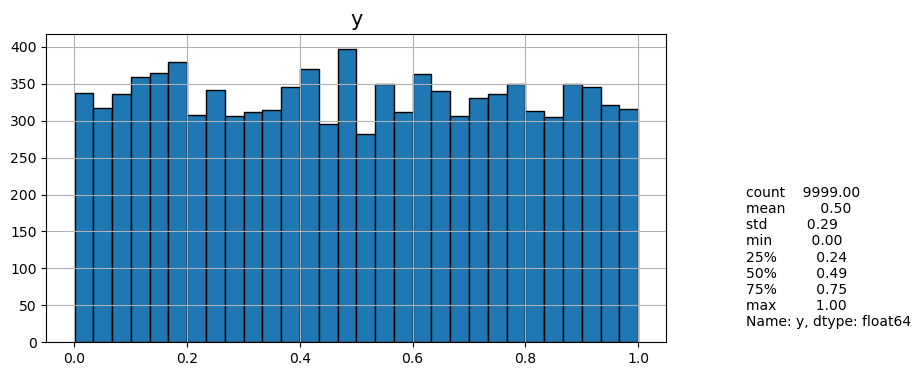

In [20]:
for column in numeric:
    desc_num_feature(column)

### Observations from Summary Statistics and Univariate EDA

The numerical features generally show approximately bell-shaped distributions, with the exception of feature 'y' which shows a uniform distribution. Most features have means and medians relatively close and show normal distributions based on their histograms. The features differ in their ranges and std. Column 'x9' shows the greatest variability.

Based on counts, it appears there may be some missing values despite the results found in previous efforts to determine null values. This will be further investigated in the data cleaning phase. 

## 6. Basic Data Cleaning

This dataset will be examined for basic data-quality issues identified during EDA. The cleaning process will focus on missing values, duplicate records, incorrect data types, and values that require formatting.

This process will begin by looking for observations that require cleaning and then move to cleaning and transforming the data where necessary. 

In [22]:
# determine counts of null values and their percentages
df.isnull.sum()
(df.isnull().sum() / len(df) * 100).round(2)

# determine datatypes of 'x6' and 'x10' since all others have already been determined as numerical
df[['x6', 'x10']].head(10)


AttributeError: 'function' object has no attribute 'sum'